AIM to build and evaluate a decision tree model for classfication tasks and study the effect of tree depth and splitting criteri

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_DATSSET/daily_weather.csv"
df=pd.read_csv(path)
df.head(5)

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,36.160000
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,24.328697,19.426597
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,14.460000
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,12.742547
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,76.740000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number                  1095 non-null   int64  
 1   air_pressure_9am        1092 non-null   float64
 2   air_temp_9am            1090 non-null   float64
 3   avg_wind_direction_9am  1091 non-null   float64
 4   avg_wind_speed_9am      1092 non-null   float64
 5   max_wind_direction_9am  1092 non-null   float64
 6   max_wind_speed_9am      1091 non-null   float64
 7   rain_accumulation_9am   1089 non-null   float64
 8   rain_duration_9am       1092 non-null   float64
 9   relative_humidity_9am   1095 non-null   float64
 10  relative_humidity_3pm   1095 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 94.2 KB


In [5]:
df.shape

(1095, 11)

In [6]:
df.describe()

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
count,1095.000000,1092.000000,1090.000000,1091.000000,1092.000000,1092.000000,1091.000000,1089.000000,1092.000000,1095.000000,1095.000000
mean,547.000000,918.882551,64.933001,142.235511,5.508284,148.953518,7.019514,0.203079,294.108052,34.241402,35.344727
std,316.243577,3.184161,11.175514,69.137859,4.552813,67.238013,5.598209,1.593952,1598.078779,25.472067,22.524079
min,0.000000,907.990000,36.752000,15.500000,0.693451,28.900000,1.185578,0.000000,0.000000,6.090000,5.300000
25%,273.500000,916.550000,57.281000,65.972506,2.248768,76.553003,3.067477,0.000000,0.000000,15.092243,17.395000
50%,547.000000,918.921045,65.715479,166.000000,3.871333,177.300000,4.943637,0.000000,0.000000,23.179259,24.380000
75%,820.500000,921.160073,73.450974,191.000000,7.337163,201.233153,8.947760,0.000000,0.000000,45.400000,52.060000
max,1094.000000,929.320000,98.906000,343.400000,23.554978,312.200000,29.840780,24.020000,17704.000000,92.620000,92.250000


In [7]:
df.columns

Index(['number', 'air_pressure_9am', 'air_temp_9am', 'avg_wind_direction_9am',
       'avg_wind_speed_9am', 'max_wind_direction_9am', 'max_wind_speed_9am',
       'rain_accumulation_9am', 'rain_duration_9am', 'relative_humidity_9am',
       'relative_humidity_3pm'],
      dtype='object')

In [8]:
df.isnull().any().any()

np.True_

In [9]:
df.isnull().sum()

,0
number,0
air_pressure_9am,3
air_temp_9am,5
avg_wind_direction_9am,4
avg_wind_speed_9am,3
max_wind_direction_9am,3
max_wind_speed_9am,4
rain_accumulation_9am,6
rain_duration_9am,3
relative_humidity_9am,0


In [10]:
#print missing value
df[df.isnull().any(axis=1)]

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
16,16,917.890000,NaN,169.200000,2.192201,196.800000,2.930391,0.000,0.000000,48.990000,51.190000
111,111,915.290000,58.820000,182.600000,15.613841,189.000000,NaN,0.000,0.000000,21.500000,29.690000
177,177,915.900000,NaN,183.300000,4.719943,189.900000,5.346287,0.000,0.000000,29.260000,46.500000
262,262,923.596607,58.380598,47.737753,10.636273,67.145843,13.671423,0.000,NaN,17.990876,16.461685
277,277,920.480000,62.600000,194.400000,2.751436,NaN,3.869906,0.000,0.000000,52.580000,54.030000
334,334,916.230000,75.740000,149.100000,2.751436,187.500000,4.183078,NaN,1480.000000,31.880000,32.900000
358,358,917.440000,58.514000,55.100000,10.021491,NaN,12.705819,0.000,0.000000,13.880000,25.930000
361,361,920.444946,65.801845,49.823346,21.520177,61.886944,25.549112,NaN,40.364018,12.278715,7.618649
381,381,918.480000,66.542000,90.900000,3.467257,89.400000,4.406772,NaN,0.000000,20.640000,14.350000
409,409,NaN,67.853833,65.880616,4.328594,78.570923,5.216734,0.000,0.000000,18.487385,20.356594


In [11]:
df.drop('number', axis=1, inplace=True, errors='ignore')
df.columns

Index(['air_pressure_9am', 'air_temp_9am', 'avg_wind_direction_9am',
       'avg_wind_speed_9am', 'max_wind_direction_9am', 'max_wind_speed_9am',
       'rain_accumulation_9am', 'rain_duration_9am', 'relative_humidity_9am',
       'relative_humidity_3pm'],
      dtype='object')

In [12]:
df.shape

(1095, 10)

In [13]:
clean_data = df.copy()
clean_data ['high_humidity_label'] = (clean_data['relative_humidity_3pm']>24.99)*1
print(clean_data['high_humidity_label'])

0       1
1       0
2       0
3       0
4       1
       ..
1090    1
1091    1
1092    1
1093    1
1094    0
Name: high_humidity_label, Length: 1095, dtype: int64


In [14]:
clean_data.columns

Index(['air_pressure_9am', 'air_temp_9am', 'avg_wind_direction_9am',
       'avg_wind_speed_9am', 'max_wind_direction_9am', 'max_wind_speed_9am',
       'rain_accumulation_9am', 'rain_duration_9am', 'relative_humidity_9am',
       'relative_humidity_3pm', 'high_humidity_label'],
      dtype='object')

In [15]:
clean_data.drop('relative_humidity_9am', axis=1, inplace=True, errors='ignore')
clean_data.drop('relative_humidity_3pm', axis=1, inplace=True, errors='ignore')
clean_data.columns

Index(['air_pressure_9am', 'air_temp_9am', 'avg_wind_direction_9am',
       'avg_wind_speed_9am', 'max_wind_direction_9am', 'max_wind_speed_9am',
       'rain_accumulation_9am', 'rain_duration_9am', 'high_humidity_label'],
      dtype='object')

In [16]:
X=clean_data.iloc[:,:-1]
print(X)

      air_pressure_9am  air_temp_9am  avg_wind_direction_9am  \
0           918.060000     74.822000              271.100000   
1           917.347688     71.403843              101.935179   
2           923.040000     60.638000               51.000000   
3           920.502751     70.138895              198.832133   
4           921.160000     44.294000              277.800000   
...                ...           ...                     ...   
1090        918.900000     63.104000              192.900000   
1091        918.710000     49.568000              241.600000   
1092        916.600000     71.096000              189.300000   
1093        912.600000     58.406000              172.700000   
1094        921.530000     77.702000               97.100000   

      avg_wind_speed_9am  max_wind_direction_9am  max_wind_speed_9am  \
0               2.080354              295.400000            2.863283   
1               2.443009              140.471548            3.533324   
2              

In [17]:
Y=clean_data.iloc[:,-1]
print(Y)

0       1
1       0
2       0
3       0
4       1
       ..
1090    1
1091    1
1092    1
1093    1
1094    0
Name: high_humidity_label, Length: 1095, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [19]:
X_train

,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am
636,919.480000,36.752000,311.400000,3.511996,133.900000,5.234440,0.270,310.000000
1041,917.600000,74.120000,179.100000,2.147462,190.700000,3.467257,0.000,0.000000
249,919.550000,59.090000,49.000000,20.893020,58.500000,24.695818,0.000,0.000000
706,917.440000,64.778000,34.600000,19.170576,62.400000,25.859026,0.119,681.000000
479,918.940000,46.634000,260.200000,2.773806,287.200000,4.004123,0.000,0.000000
...,...,...,...,...,...,...,...,...
330,918.100000,61.988000,191.100000,11.050484,199.400000,12.728189,0.000,0.000000
466,913.830000,52.286000,175.200000,5.502872,182.000000,6.352910,0.000,0.000000
121,920.590000,75.002000,89.700000,1.163209,91.100000,1.789552,0.000,0.000000
1044,923.107768,60.601640,51.208517,17.188835,64.247358,22.195713,0.000,19.348384


In [20]:
Y_train

,high_humidity_label
636,1
1041,1
249,0
706,0
479,1
...,...
330,1
466,1
121,0
1044,0


In [21]:
X_test

,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am
533,915.870000,76.550000,224.500000,2.169832,215.800000,2.908022,0.0,0.000000
139,921.933298,64.618269,73.213445,3.815592,92.033194,4.733501,0.0,0.000000
88,915.914436,69.388873,46.736171,10.976951,64.644682,14.297617,0.0,9.397157
841,918.370000,72.932000,184.500000,2.013246,186.700000,2.773806,0.0,0.000000
985,919.700000,78.530000,187.000000,4.943637,193.800000,5.726566,0.0,0.000000
...,...,...,...,...,...,...,...,...
235,915.836126,70.552337,178.217736,3.337398,186.363765,4.142721,0.0,0.000000
424,915.300000,80.276000,148.700000,1.342164,145.600000,1.789552,0.0,0.000000
590,918.000000,60.314000,187.500000,4.272555,207.600000,5.547611,0.0,0.000000
305,916.100000,56.426000,184.100000,10.245185,194.800000,12.079476,0.0,0.000000


In [22]:
Y_test

,high_humidity_label
533,1
139,0
88,0
841,0
985,0
...,...
235,0
424,0
590,1
305,1


In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler = scaler.transform(X_test)

In [24]:
humidity_classifier = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
humidity_classifier.fit(X_train, Y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.4642857142857143, 0.9, 'x[0] <= -0.006\ngini = 0.5\nsamples = 766\nvalue = [381, 385]'),
 Text(0.2857142857142857, 0.7, 'x[1] <= 0.722\ngini = 0.358\nsamples = 373\nvalue = [87, 286]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.21428571428571427, 0.5, 'x[2] <= -1.059\ngini = 0.173\nsamples = 230\nvalue = [22, 208]'),
 Text(0.14285714285714285, 0.3, 'x[4] <= -1.251\ngini = 0.5\nsamples = 24\nvalue = [12, 12]'),
 Text(0.07142857142857142, 0.1, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.21428571428571427, 0.1, 'gini = 0.375\nsamples = 16\nvalue = [12, 4]'),
 Text(0.2857142857142857, 0.3, 'gini = 0.092\nsamples = 206\nvalue = [10, 196]'),
 Text(0.35714285714285715, 0.5, 'gini = 0.496\nsamples = 143\nvalue = [65, 78]'),
 Text(0.6428571428571429, 0.7, 'x[1] <= -0.87\ngini = 0.377\nsamples = 393\nvalue = [294.0, 99.0]'),
 Text(0.5535714285714286, 0.8, '  False'),
 Text(0.5, 0.5, 'x[4] <= -0.951\ngini = 0.468\nsamples = 67\nvalue = [25, 42]'),
 Text(0.42857142857142855, 0.3, 'x[3] 

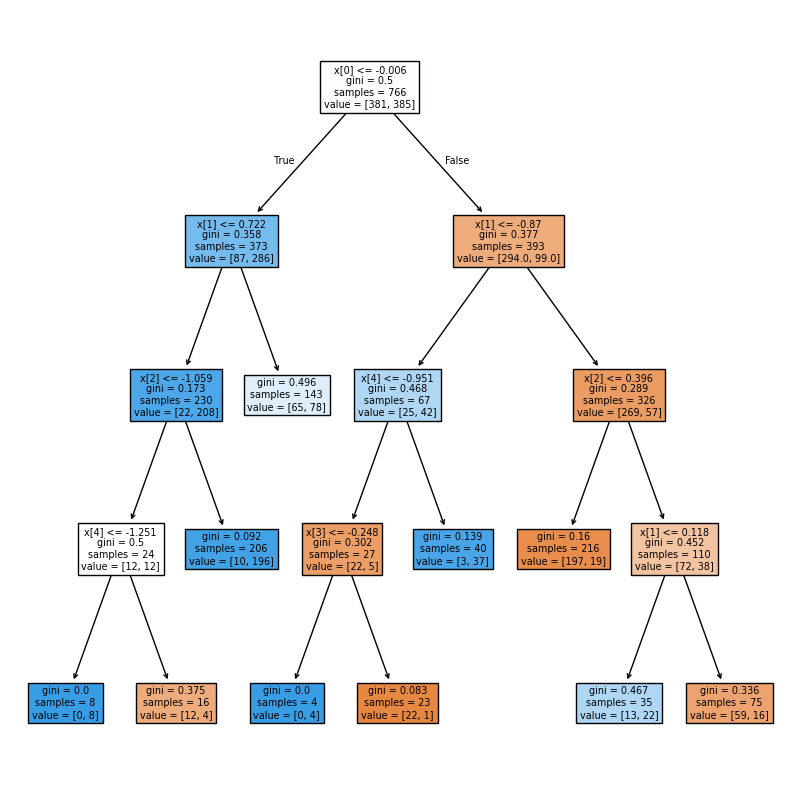

In [25]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(humidity_classifier, filled=True)

In [27]:
Y_pred = humidity_classifier.predict(X_test)
print(Y_pred)

[1 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1
 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1
 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0
 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 1 0 1 0 0
 0 0 1 0 1 1 0 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1
 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0
 0 0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1]


In [28]:
#Accuraccy
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

In [29]:
print(confusion_matrix(Y_test, Y_pred))

[[111  56]
 [ 24 138]]


In [30]:
print(classification_report(Y_test, Y_pred))


              precision    recall  f1-score   support

           0       0.82      0.66      0.74       167
           1       0.71      0.85      0.78       162

    accuracy                           0.76       329
   macro avg       0.77      0.76      0.76       329
weighted avg       0.77      0.76      0.75       329

